In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pyarrow
from pathlib import Path
import scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

#Desactivar notacion científica
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
from matplotlib.ticker import PercentFormatter

sns.set_theme(
    style="whitegrid",
    context="notebook"
)
#path de reports/graphics
GRAPHICS_PATH = Path("../reports/graphics")
GRAPHICS_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
Path.cwd()

WindowsPath('g:/Mi unidad/DS4B_Mastery_Edition/proyectos/ecommerce-growth-analytics/notebooks')

In [4]:
df = pd.read_parquet("../data/intermediate/df_processed.parquet")

## 1. Analisis de sesiones

### Analisis de eventos por sesion

Estadísticos de eventos por sesion

In [5]:
df.event.unique()

<ArrowStringArray>
['view', 'cart', 'remove_from_cart', 'purchase']
Length: 4, dtype: str

In [6]:
session_event = df.groupby(['user_session','event']).product_id.count().unstack().fillna(0)

In [7]:
session_event = session_event[['view','cart','remove_from_cart','purchase']]

In [8]:
session_event.describe().T

,count,mean,std,min,25%,50%,75%,max
event,,,,,,,,
view,446054.00,2.16,5.29,0.00,1.00,1.00,2.00,1005.00
cart,446054.00,1.29,6.25,0.00,0.00,0.00,0.00,778.00
remove_from_cart,446054.00,0.92,8.93,0.00,0.00,0.00,0.00,2422.00
purchase,446054.00,0.29,2.37,0.00,0.00,0.00,0.00,259.00


<Axes: >

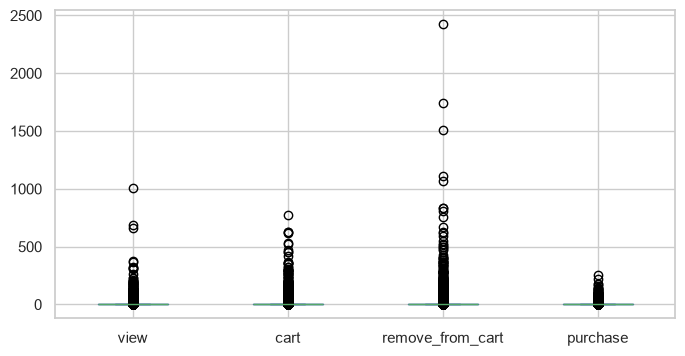

In [9]:
session_event.plot(kind='box',figsize=(8, 4))

Aunque graficamente remove_from_cart parece mayor al resto de eventos, realmente los datos muestran que de media, por sesion hay 0.92 eliminados de carrito frente a 1.29 añadidos a carrito y 2.16 vistas de producto con lo cual no podemos concluir que el grafico muestre datos anómalos.

#### Analisis detallado de sesiones con más eventos por minuto (deteccion de anomalias)

In [5]:
df["is_add_to_cart"] = df["event"].eq("add_to_cart")
df["is_remove_from_cart"] = df["event"].eq("remove_from_cart")
df["is_purchase"] = df["event"].eq("purchase")
df["is_view"] = df["event"].eq("view")

In [11]:
#dataset de analisis de sesiones
df_events_session = (
    df
    .reset_index()
    .groupby("user_session")
    .agg(
        session_start=("date_time", "min"),
        session_end=("date_time", "max"),
        events=("event", "size"),
        views=("is_view", "sum"),
        add_to_cart=("is_add_to_cart", "sum"),
        remove_from_cart=("is_remove_from_cart", "sum"),
        purchase=("is_purchase", "sum")
    )
    .assign(
        session_duration_seconds = lambda x: (x['session_end'] - x['session_start']).dt.total_seconds().clip(lower=1),
        events_per_second = lambda x: x['events'] / (x['session_duration_seconds'])
    )
    .sort_values("events_per_second", ascending=False)
)

In [15]:
df_events_session['session_duration_minutes'] = df_events_session['session_duration_seconds'] / 60

- Despues de análisis de eventos con con ventanas temporales **no se puede concluir que haya patrones extremadamente anómalos** debido a que las sesiones con mas eventos por minuto son provocadas por acciones de **delete from cart y purchase** (lo que provoca que grandes cantidades de productos sean eliminados simultaneamente, quedando registrados como eventos de forma individual).

### Analisis de temporalidad de las sesiones

In [16]:
#Duracion de las sesiones
df_events_session.session_duration_minutes.describe()

count   446054.00
mean       260.88
std       5211.85
min          0.02
25%          0.02
50%          0.02
75%          1.65
max     217502.07
Name: session_duration_minutes, dtype: float64

In [19]:
#Duracion sesiones > 60min
df_events_session.loc[df_events_session["session_duration_minutes"] > 60].session_duration_minutes.describe( percentiles=[.25, .50, .75, .90, .95, .99])

count    17503.00
mean      6575.83
std      25510.20
min         60.02
25%         88.75
50%        159.37
75%       1060.59
90%       6425.80
95%      32764.22
99%     150287.02
max     217502.07
Name: session_duration_minutes, dtype: float64

In [22]:
df_events_session.reset_index(inplace=True)
a = df_events_session[df_events_session['session_duration_minutes'] <= 60].user_session.count()
b = df_events_session[df_events_session['session_duration_minutes'] > 60].user_session.count()

print(f"sesiones con duracion <= 60 min: {a}")
print(f"sesiones con duracion > 60 min: {b}")
print(f"Porcentaje sesiones > 60 min respecto al total: {(b/(a+b))*100}%")

sesiones con duracion <= 60 min: 428551
sesiones con duracion > 60 min: 17503
Porcentaje sesiones > 60 min respecto al total: 3.923964363059181%


Debido a que la duracion de las sesiones es bastante variable con sesiones de duracion extremadamente largas, se valorará si ignorar las sesiones con duracion > 60min si no representan un alto porcentaje de los ingresoso totales.

In [23]:
#calculamos sales solo de eventos purchase por user_session
session_sales = (
    df.loc[df["event"].eq("purchase")]
      .groupby("user_session", as_index=False)
      .agg(
          revenue=("price", "sum"),
      )
)

In [24]:
#merge de sales en dataset de sesiones
df_events_session = df_events_session.merge(
    session_sales,
    on="user_session",
    how="left",
)

In [25]:
#Rellenar NaN con 0
df_events_session["revenue"] = (
    df_events_session["revenue"].fillna(0)
)

In [27]:
#Categorizar tipo de sesion
df_events_session['duration_group'] = np.where((df_events_session['session_duration_minutes'] <= 60), 1, 0)

In [28]:
#Suma de renevue total segun tipo de sesion para comprovar relevancia de cada grupo
a = df_events_session.groupby('duration_group')["revenue"].sum().iloc[0]
b = df_events_session.groupby('duration_group')["revenue"].sum().iloc[1]

print(f"revenue total grupo >60min: {a}")
print(f"revenue total grupo <= 60min: {b}")
print(f"Porcentaje de revenue de sesiones >60min sobre el total: {(a/(a+b))*100}%")


revenue total grupo >60min: 131595.28
revenue total grupo <= 60min: 489954.32
Porcentaje de revenue de sesiones >60min sobre el total: 21.172128499479367%


La renevue total de las sesiones >60min **es suficientemente relevante como para no ignorarla**. Se comprovaran gaps entre eventos en sesiones > 60min.

#### Analisis de gaps en sesiones de usuario >60min para determinar timeouts y convertir sesiones muy largas

In [29]:
#creamos dataset temporal para calcular temporalidad de los gaps entre evento dentro de mismo usuario-sesion de forma ordenada
df_session_gaps = (
    df.assign(timestamp=df.index)
      .sort_values(["user_id", "user_session", "timestamp"])
)

In [30]:
#variable de tiempo entre eventos 
df_session_gaps["gap_minutes"] = (
    df_session_gaps
    .groupby("user_session")["timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

In [32]:
#Filtro sesiones > 60min
long_session_ids = df_events_session.loc[df_events_session["session_duration_minutes"] > 60, "user_session"]

#Aplicamos filtro a long_session_gaps
long_session_gaps = df_session_gaps[df_session_gaps["user_session"].isin(long_session_ids)]

In [ ]:
long_session_gaps["gap_minutes"].describe(percentiles=[.50, .75, .90, .95, .99])

count   467122.00
mean       246.40
std       4465.62
min          0.00
50%          0.35
75%          1.27
90%          5.12
95%         31.08
99%       1758.60
max     213018.47
Name: gap_minutes, dtype: float64

Esto sigue sin ofrecernos informacion relevante ya que estamos usando todos los gaps dentro de las sesiones más largas, y muchos de esos gaps pueden ser pequeños. Vamos a seguir filtrando para obtener conclusiones.

In [33]:
#Gap maximo de cada sesion sesion larga
max_gap_per_session = (
    long_session_gaps
    .groupby("user_session")["gap_minutes"]
    .max()
)

max_gap_per_session.describe(
    percentiles=[.25, .50, .75, .90, .95, .99]
)

count    17503.00
mean      5538.80
std      22007.21
min          2.77
25%         54.68
50%        111.12
75%        963.55
90%       5286.14
95%      27417.65
99%     130897.29
max     213018.47
Name: gap_minutes, dtype: float64

Ahora si podemos sacar conclusiones más fiables de los gaps de sesiones largas:
- Las 17.503 sesiones largas no forman un grupo homogéneo. Una parte parece perfectamente recuperable como sesión real. Otra parte contiene períodos de inactividad incompatibles con una navegación continua.
- Por ejemplo, el P25 nos dice que al menos un 25% de estas sesiones, aunque duren >60 minutos en total, no tienen ningún gap superior a ~55 minutos.

Va a realizarse un analisis de estos gaps en **ventanas personalizadas** para tomar acciones finales sobre las sesiones

In [34]:
# gaps de todo el dataset - analisis de ventanas personalizadas
max_gap_all_sessions = (
    df_session_gaps
    .groupby("user_session")["gap_minutes"]
    .max()
)

gap_thresholds = pd.Series({
    "> 30 min": max_gap_all_sessions.gt(30).mean() * 100,
    "> 60 min": max_gap_all_sessions.gt(60).mean() * 100,
    "> 2 h":    max_gap_all_sessions.gt(120).mean() * 100,
    "> 6 h":    max_gap_all_sessions.gt(360).mean() * 100,
    "> 24 h":   max_gap_all_sessions.gt(1440).mean() * 100,
    "> 7 days": max_gap_all_sessions.gt(10080).mean() * 100
})

gap_thresholds.round(2)

> 30 min   4.11
> 60 min   2.85
> 2 h      1.87
> 6 h      1.41
> 24 h     0.75
> 7 days   0.30
dtype: float64

In [35]:
# gaps de sesiones >60min - analisis de ventanas personalizadas
pd.Series({
    "> 30 min": max_gap_per_session.gt(30).mean() * 100,
    "> 60 min": max_gap_per_session.gt(60).mean() * 100,
    "> 2 h":    max_gap_per_session.gt(120).mean() * 100,
    "> 6 h":    max_gap_per_session.gt(360).mean() * 100,
    "> 24 h":   max_gap_per_session.gt(1440).mean() * 100,
    "> 7 days": max_gap_per_session.gt(10080).mean() * 100
}).round(2)

> 30 min   86.33
> 60 min   72.58
> 2 h      47.67
> 6 h      35.91
> 24 h     19.23
> 7 days    7.54
dtype: float64

#### Conclusiones (gaps):
- **4,11%** de todas las sesiones tienen algún gap >30 min.
- **2,85%** de todas las sesiones tienen algún gap >60 min.

Debido a que aproximadamente el 97,5% de todo el dataset contiene sesiones con gaps <= 60min, **no es recomendable aplicar cambios sobre todo el dataset**, solo sobre las sesiones largas. Ademas, dentro de las sesiones >60min:
- **86,33%** de todas las sesiones >60min. tienen gaps >30 min
- **72,58%** de todas las sesiones >60min. tienen gaps >60 min

Se ha decidido usar un **threshold de 60min** para dividir sesiones largas ya que **solo afectará al 2,85% de las sesiones totales**.

In [51]:
#Nuevo dataset especifico para análisis de sesiones
#resetear indice para oredenar por timestamp a futuro
df_event_session = df.reset_index().copy()
#renombrar
df_event_session.rename(columns={"date_time": "timestamp"}, inplace=True)
#ordenamos
df_event_session = df_event_session.sort_values(
    ["user_id", "timestamp", "user_session"],
    ascending=True
)

In [52]:
#Variable para calcular gaps
df_event_session["gap_minutes"] = (
    df_event_session
    .groupby(["user_id", "user_session"])["timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

In [53]:
#Variable threshold sesion nueva
df_event_session["new_session"] = df_event_session["gap_minutes"].isna() | df_event_session["gap_minutes"].gt(60)

In [ ]:
# Numeramos nuevas sesiones unicas de cada usuario
df_event_session["analytical_session_number"] = (
    df_event_session
    .groupby("user_id")["new_session"]
    .cumsum()
)

In [55]:
#Variable para generar nuevas sub-sesiones a partir de las sesiones anómalas
df_event_session["analytical_session"] = (
    df_event_session["user_id"].astype(str)
    + "_"
    + df_event_session["analytical_session_number"].astype(str)
)

- Ahora vamos a generar el dataset agrupado de ususario y sesiones para calcular CR

In [56]:
df_sessions = df_event_session.copy()

In [57]:
#Dataset de sesiones final con variables necesarias para calcular el Conversion Rate
df_sessions["viewed"] = df_sessions["event"].eq("view")
df_sessions["added_to_cart"] = df_sessions["event"].eq("cart")
df_sessions["removed_from_cart"] = df_sessions["event"].eq("remove_from_cart")
df_sessions["purchased"] = df_sessions["event"].eq("purchase")

sessions = (
    df_sessions
    .groupby(
        ["user_id", "analytical_session_number"],
        as_index=False,
        sort=False
    )
    .agg(
        session_start=("timestamp", "min"),
        session_end=("timestamp", "max"),
        viewed=("viewed", "max"),
        added_to_cart=("added_to_cart", "max"),
        removed_from_cart=("removed_from_cart", "max"),
        purchased=("purchased", "max")
    )
)

#### Conversion Rate (CR) por sesion

In [59]:
#Calculamos Conversion Rate
conversion_rate = sessions["purchased"].mean() * 100
conversion_rate

np.float64(3.3567233358271205)

#### Funnel de conversion basado en eventos por sesion

In [60]:
#Funnel de conversion
funnel = (
    sessions[
        ["viewed", "added_to_cart", "purchased"]
    ]
    .sum()
    .rename({
        "viewed": "Viewed product",
        "added_to_cart": "Added to cart",
        "purchased": "Purchased"
    })
)

funnel

Viewed product    436331
Added to cart     101867
Purchased          15614
dtype: int64

In [61]:
funnel_pct = funnel / funnel.iloc[0] * 100
funnel_pct

Viewed product   100.00
Added to cart     23.35
Purchased          3.58
dtype: float64

In [ ]:
import plotly.graph_objects as go

funnel = (
    sessions[["viewed", "added_to_cart", "purchased"]]
    .sum()
    .rename({
        "viewed": "Viewed product",
        "added_to_cart": "Added to cart",
        "purchased": "Purchased"
    })
)
percentages = funnel / funnel.iloc[0] * 100

fig = go.Figure(
    go.Funnel(
        y=funnel.index,
        x=funnel.values,
        text=[
            f"{value:,.0f}<br>{pct:.2f}%"
            for value, pct in zip(funnel.values, percentages)
        ],
        textinfo="text"
    )
)

fig.update_layout(title="Session-Based Conversion Funnel", width=800, height=400)
fig.write_image("../reports/graphics/session_based_conversion_funnel.png")
fig.show()

### Insight 1: CR Global de 3,35% y CR Funnel de 3,57%

1. Purchase rate por sesion:

- La **tasa de conversión por sesión es del 3,35%**, lo que significa que aproximadamente **3 de cada 100 sesiones analíticas finalizan con al menos una compra**.

    Para calcular este indicador se mantuvieron las sesiones originales como unidad de referencia, pero se corrigieron aquellas que presentaban **periodos de inactividad superiores a 60 minutos**, dividiéndolas en nuevas sesiones analíticas. Esta metodología permite reducir la distorsión provocada por sesiones anormalmente largas, sin eliminar los eventos ni las compras asociadas a ellas. Un CR del **3,35%** indica que existe un volumen considerable de sesiones que no culminan en compra, por lo que resulta relevante analizar las etapas del funnel (`view → cart → purchase`) para identificar los principales puntos de abandono y posibles oportunidades de mejora.

2. Funnel de conversion basado en eventos por sesion:

- En cada sesion analitica establecida **con almenos 1 vista de producto**, hubo un **23,15%** de eventos en los que se añadió almenos un producto al carrito y un **3,57%** de las sesiones en las que se genero almenos una venta.

    La diferencia entre CR Global y CR Funnel se debe a que CR Global se calcula como **sesiones con compra/todas las sesiones analiticas** y CR del Funnel se calcula como **sesiones con compra/sesiones con almenos 1 view**.

## 2. Analisis de eventos

#### Comparacion de tipo de evento

In [ ]:
df.event.unique()

<ArrowStringArray>
['view', 'cart', 'remove_from_cart', 'purchase']
Length: 4, dtype: str

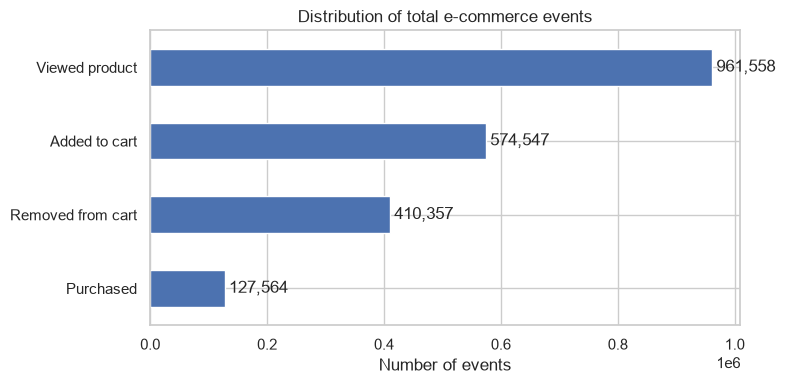

In [34]:
import matplotlib.pyplot as plt

event_labels = {
    "view": "Viewed product",
    "cart": "Added to cart",
    "remove_from_cart": "Removed from cart",
    "purchase": "Purchased"
}
event_counts = (
    df["event"]
    .value_counts()
    .rename(index=event_labels)
    .sort_values()
)
ax = event_counts.plot.barh(figsize=(8, 4))
ax.set(
    title="Distribution of total e-commerce events",
    xlabel="Number of events",
    ylabel=""
)
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
plt.tight_layout()
plt.show()

### Analisis de eventos por hora

In [35]:
events_by_hour = (
    df.groupby(["hour", "event"])
      .size()
      .unstack(fill_value=0)
      .reindex(range(24), fill_value=0)
      .reset_index()
)

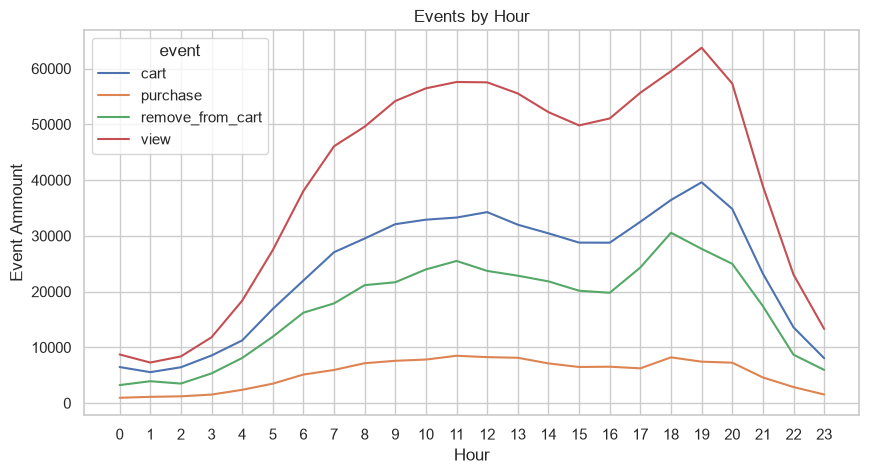

In [36]:
events_by_hour.set_index("hour").plot(figsize=(10, 5))

plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Event Ammount")
plt.title("Events by Hour")
plt.show()

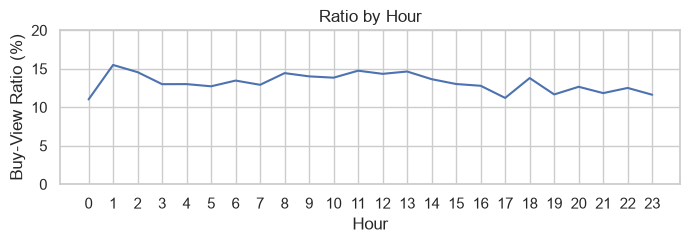

In [37]:
events_by_hour['buys_views_ratio_pct'] = events_by_hour['purchase'] / events_by_hour['view'] * 100

events_by_hour['buys_views_ratio_pct'].plot(figsize=(8, 2))
plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylim(0, 20)
plt.ylabel("Buy-View Ratio (%)")
plt.title("Ratio by Hour")
plt.show()

### Analisis de eventos mensual, semanal y diario

#### Analisis mensual

In [6]:
#Ventas mensuales (evento purchase)
df_purchase = df[df.event == 'purchase']

sales_by_month = df_purchase.groupby('month')['price'].sum()
print(sales_by_month)
print(f"media ventas mensuales:{sales_by_month.mean():.2f}")

month
December   102034.20
February   121330.67
January    135174.45
November   146491.24
October    116519.04
Name: price, dtype: float64
media ventas mensuales:124309.92


#### Analisis semanal

In [7]:
res = df.groupby("event").resample("W").size().unstack(level=0)
res.drop(columns=['remove_from_cart','cart'], inplace=True)

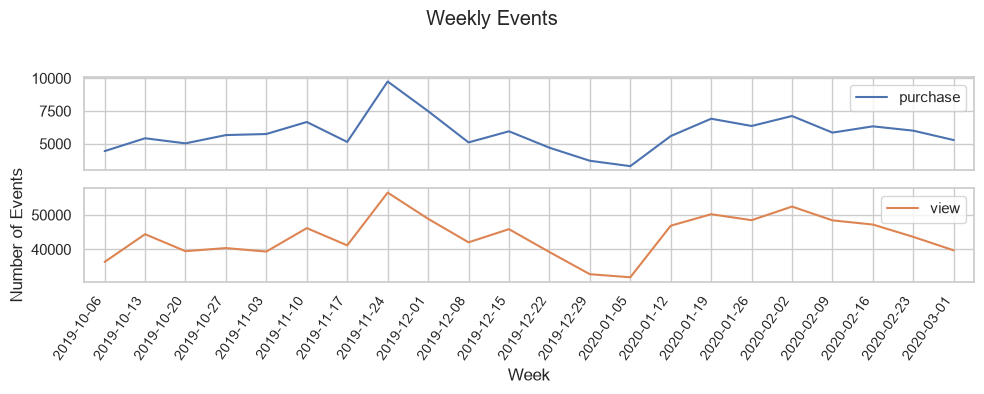

In [8]:
res.index = res.index.astype(str)
res.plot(figsize=(10, 4), subplots=True)

plt.suptitle("Weekly Events")
plt.xlabel("Week")
plt.ylabel("Number of Events")

plt.xticks(
    ticks=range(len(res.index)),
    labels=res.index,
    fontsize=10,
    rotation= 55,
    ha="right"
)

plt.xlim(-0.5, len(res.index) - 0.5)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

Se observan picos de ventas en las dos ultimas semanas de Noviembrey primera de Diciembre, debido posiblemente al **Black Friday y compras navideñas**. Para potenciar las ventas en esas franjas, en caso de disponer de fondos para invertir en publicidad en el último trimestre del año, **se deberia concentrar en las primeras semanas de Noviembre**.

#### Análisis diario en franja de ventas mas alta

In [15]:
#Dataset a nivel diario en franja de mas ventas
res_dia = df.loc['2019-11-01' : '2020-01-31'].groupby('event').resample('D').size().unstack(level=0)
res_dia.drop(columns=['remove_from_cart','cart'], inplace=True)
res_dia.index = res_dia.index.astype(str)

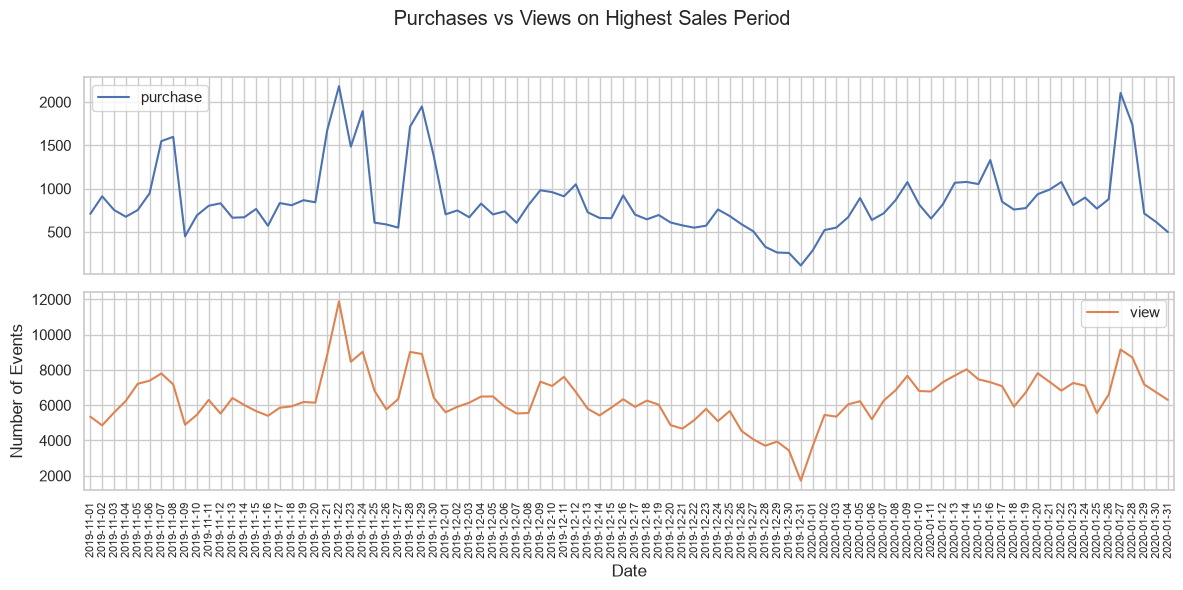

In [18]:
res_dia.index = res_dia.index.astype(str)
res_dia.plot(figsize=(12, 6), subplots=True)

plt.suptitle("Purchases vs Views on Highest Sales Period")
plt.xlabel("Date")
plt.ylabel("Number of Events")

plt.xticks(
    ticks=range(len(res_dia.index)),
    labels=res_dia.index,
    fontsize=8,
    rotation= 90,
    ha="center"
)
plt.xlim(-0.5, len(res_dia.index) - 0.5)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(GRAPHICS_PATH / "purchases_views_on_high_sales_period.png", dpi=300, bbox_inches="tight")
plt.show()

#### Analisis de evento compra en dias señalados vs normales

In [6]:
special_days = [
    "is_unity_day",
    "is_singles_day",
    "is_black_friday",
    "is_cyber_monday",
    "is_new_year_period",
    "is_orthodox_christmas",
    "is_valentines_day",
    "is_defender_day"]

#Categorizamso dias especiales y no especiales en una sola variable
df["day_type"] = (
    df[special_days]
    .idxmax(axis=1)
    .where(df[special_days].any(axis=1), "normal_day")
)

In [7]:
df[df.event.eq("purchase")].groupby("date").agg(
    purchase_events = ("event", "count"),
    revenue = ("price", "sum"),
    day_type = ("day_type", "first")
).sort_values("purchase_events", ascending=False).head(20)

,purchase_events,revenue,day_type
date,,,
2019-11-22,2183,10167.96,is_black_friday
2020-01-27,2105,10360.00,is_cyber_monday
2019-11-29,1949,8356.91,is_black_friday
2019-11-24,1896,8044.54,is_black_friday
2020-01-28,1738,8531.21,is_cyber_monday
2019-11-28,1715,7871.07,is_black_friday
2019-11-21,1671,7782.93,normal_day
2019-11-08,1598,8335.01,normal_day
2019-11-07,1549,8105.19,normal_day


#### Insight 2 : Diciembre tiene una tendencia de compra decreciente y ventas se concentran sobretodo en Black Friday y Cyber Monday
- Diciembre tiene una tendencia claramente decreciente la cual empieza de forma abrupta el dia 1 de Diciembre, marcando una tendencia de compra bastante plana y decreciente en su segunda mitad.
- La mayor parte de las ventas se concentran en los eventos siguientes por orden de relevancia:
    1. Durante la Black Friday week (22 a 29 Noviembre) y en el propio dia del Black Friday (29 Noviembre).
    2. Durante el período comercial del Cyber Monday Ruso (27 a 29 de Enero).
    3. Días previos al singles day (11 de Noviembre).


Acciones:
- Invertir la mayor parte del presupuesto de marketing en **Noviembre**.
- Poner especial foco en **la semana del BF, en el propio BF y en el Cyber Monday.**

## 3. Customer analysis

In [15]:
#Dataset de clientes a partir del dataset de sesiones con variable sesion analítica
customers_total_sessions = df_sessions.groupby('user_id').agg(
    total_sessions = ("analytical_session", "nunique"))

customers = df_sessions[df_sessions["event"].eq("purchase")].groupby('user_id').agg(
    purchase_sessions= ("analytical_session", "nunique"),
    total_sales_sum= ("price", "sum"),
    total_sales_mean= ("price", "mean"),
    first_purchase_date= ("date", "min"),
    last_purchase_date= ("date", "max"),
    total_products= ("purchased", "sum")
)
customers = pd.merge(customers, customers_total_sessions, how='left', left_index=True, right_index=True)
customers['products_by_session'] = customers['total_products'] / customers['purchase_sessions']
customers['sales_by_session'] = customers['total_sales_sum'] / customers['purchase_sessions']

In [16]:
customers = customers[['first_purchase_date','last_purchase_date','total_sales_sum','total_sales_mean','total_sessions', 'purchase_sessions', 'total_products','products_by_session','sales_by_session']]
customers.sort_values('total_sales_sum', ascending=False).head(5)

,first_purchase_date,last_purchase_date,total_sales_sum,total_sales_mean,total_sessions,purchase_sessions,total_products,products_by_session,sales_by_session
user_id,,,,,,,,,
573823111,2020-02-14,2020-02-21,1559.21,5.82,52,2,268,134.00,779.61
539751397,2019-10-10,2020-02-19,1453.37,6.16,131,13,236,18.15,111.80
556579890,2019-11-07,2020-02-27,1392.45,2.75,44,4,506,126.50,348.11
442763940,2019-11-27,2019-12-23,1241.53,6.37,38,8,195,24.38,155.19
561592095,2019-10-30,2019-10-31,1109.70,11.81,16,3,94,31.33,369.90


### 3.1. Customer overview

In [22]:
#kpi y metricas basicas
customer_kpis = pd.Series({
    "Customers": len(customers),
    "Total Sales": customers["total_sales_sum"].sum(),
    "Sales / Customer": customers["total_sales_sum"].mean(),
    "Products / Customer": customers["total_products"].mean(),
    "Purchase Sessions / Customer": customers["purchase_sessions"].mean()
})

customer_kpis

Customers                       11040.00
Total Sales                    621549.60
Sales / Customer                   56.30
Products / Customer                11.55
Purchase Sessions / Customer        1.41
dtype: float64

In [17]:
#Media vs mediana
customers["total_sales_sum"].agg(["mean", "median"])

mean     56.30
median   32.74
Name: total_sales_sum, dtype: float64

### 3.2. Purchase & Repeat Behaviour

#### 3.2.1. Repeat purchase rate

In [24]:
repeat_purchase_rate = (customers["purchase_sessions"] > 1).mean() * 100
repeat_purchase_rate

np.float64(21.73913043478261)

In [18]:
customers["customer_type"] = np.where(customers["purchase_sessions"] > 1, "Repeat", "One-time")

In [19]:
customer_by_type = (
    customers.groupby("customer_type")
    .agg(
        customers=("total_sales_sum", "size"),
        total_sales=("total_sales_sum", "sum"),
        avg_sales=("total_sales_sum", "mean"),
        avg_products=("total_products", "mean"),
        avg_purchase_sessions=("purchase_sessions", "mean")
    )
)

customer_by_type["customer_pct"] = customer_by_type["customers"] / customer_by_type["customers"].sum() * 100
customer_by_type["sales_pct"] = customer_by_type["total_sales"] / customer_by_type["total_sales"].sum() * 100

customer_by_type

,customers,total_sales,avg_sales,avg_products,avg_purchase_sessions,customer_pct,sales_pct
customer_type,,,,,,,
One-time,8640,320464.86,37.09,7.27,1.00,78.26,51.56
Repeat,2400,301084.74,125.45,27.00,2.91,21.74,48.44


#### 3.2.2. Purchase session conversion

In [20]:
#ratio de sesiones con compra sobre el total de sesiones por cliente
customers["purchase_session_rate"] =customers["purchase_sessions"] / customers["total_sessions"]
customer_purchase_session_rate = customers["purchase_sessions"].sum()/ customers["total_sessions"].sum() * 100
customer_purchase_session_rate

np.float64(10.729009207090833)

### 3.3. Customer Value

#### 3.3.1 Renevue concentration

In [21]:
sales = customers["total_sales_sum"].sort_values(ascending=False)

#10% y 20% de clientes totales para calcular concentracion
for pct in [.10, .20]:

    n = int(np.ceil(len(sales) * pct)) #cantidad de clientes que entran en cada porcentaje

    share = sales.iloc[:n].sum() / sales.sum() * 100 # ratio de ventas de los clientes top n sobre el total de ventas

    print(f"Top {pct:.0%}: {share:.2f}% of sales")

Top 10%: 42.44% of sales
Top 20%: 58.93% of sales


#### 3.3.2. High-value customers analysis

In [22]:
#threshold para top 10% de clientes
threshold = customers["total_sales_sum"].quantile(.90)

#division de clientes 
customers["value_group"] = np.where(customers["total_sales_sum"].ge(threshold), "Top 10%", "Other 90%")

#dataset resumen segun tipo de cliente
high_value_summary = (
    customers.groupby("value_group")
    .agg(
        avg_sales=("total_sales_sum", "mean"),
        avg_purchase_sessions=("purchase_sessions", "mean"),
        avg_products=("total_products", "mean"),
        avg_products_session=("products_by_session", "mean"),
        avg_sales_session=("sales_by_session", "mean")
    )
)

high_value_summary

,avg_sales,avg_purchase_sessions,avg_products,avg_products_session,avg_sales_session
value_group,,,,,
Other 90%,36.01,1.21,7.75,6.45,30.53
Top 10%,238.92,3.22,45.79,18.31,107.70


### 3.4. Customer recency & lifecycle

In [24]:
#fecha de referencia
analysis_date = customers["last_purchase_date"].max() + pd.Timedelta(days=1)
analysis_date

Timestamp('2020-03-01 00:00:00')

In [25]:
#recency
customers["recency_days"] = (analysis_date - customers["last_purchase_date"]).dt.days

In [26]:
#lifetime
customers["purchase_lifetime_days"] = (customers["last_purchase_date"]- customers["first_purchase_date"]).dt.days

In [27]:
#estadisticas de recencia y lifecycle
customers[["recency_days", "purchase_lifetime_days"]].describe( percentiles=[.25, .5, .75, .9]).T

,count,mean,std,min,25%,50%,75%,90%,max
recency_days,11040.00,69.84,43.82,1.00,31.00,70.00,105.00,132.00,152.00
purchase_lifetime_days,11040.00,11.22,28.63,0.00,0.00,0.00,0.00,49.00,151.00


In [28]:
#lifetime solo en clientes recurrentes
customers.loc[(customers["purchase_sessions"] > 1), "purchase_lifetime_days"].describe(percentiles=[.25, .5, .75, .9])

count   2400.00
mean      51.61
std       41.06
min        0.00
25%       16.00
50%       43.00
75%       82.00
90%      115.00
max      151.00
Name: purchase_lifetime_days, dtype: float64

### 3.5. Customer activity


#### Recencia segmentada

In [35]:
#porcentaje de clientes que no compra desde ciertos periodos de tiempo
inactive_15 = customers["recency_days"].gt(15).mean() * 100
inactive_30 = customers["recency_days"].gt(30).mean() * 100
inactive_60 = customers["recency_days"].gt(60).mean() * 100
inactive_90 = customers["recency_days"].gt(90).mean() * 100

print(f"Porcentaje de clientes que no compran desde hace 15 dias: {inactive_15:.2f}%")
print(f"Porcentaje de clientes que no compran desde hace 30 dias: {inactive_30:.2f}%")
print(f"Porcentaje de clientes que no compran desde hace 60 dias: {inactive_60:.2f}%")
print(f"Porcentaje de clientes que no compran desde hace 90 dias: {inactive_90:.2f}%")

Porcentaje de clientes que no compran desde hace 15 dias: 87.47%
Porcentaje de clientes que no compran desde hace 30 dias: 75.34%
Porcentaje de clientes que no compran desde hace 60 dias: 54.28%
Porcentaje de clientes que no compran desde hace 90 dias: 36.85%


<Axes: xlabel='recency_segment'>

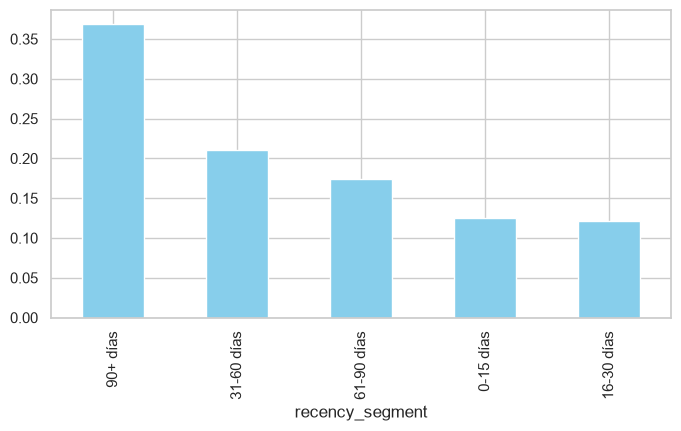

In [29]:
#segmentacion de la recencia (agrupacion por rangos de dias)
customers["recency_segment"] = pd.cut(
    customers["recency_days"],
    bins=[0, 15, 30, 60, 90, np.inf],
    labels=[
        "0-15 días",
        "16-30 días",
        "31-60 días",
        "61-90 días",
        "90+ días"
    ]
)
customers["recency_segment"].value_counts(normalize=True).plot(kind='bar', figsize=(8, 4), color='skyblue')

#### Revenue potencial "dormido"

In [37]:
customers.loc[customers["recency_days"] > 60, "total_sales_sum"].sum() / customers["total_sales_sum"].sum() * 100

np.float64(43.338549328967474)

#### Revenue de one-time purchase customers

In [38]:
revenue_from_one_time_customers = (
    customers.loc[customers["purchase_sessions"] == 1, "total_sales_sum"].sum() /
    customers["total_sales_sum"].sum() * 100
)
revenue_from_one_time_customers

np.float64(51.55901636812251)

### Insight 3: Insights estratégicos de clientes

#### 3.1. La recurrencia impulsa una parte desproporcionada del negocio
Aunque solo el **21,74% de los clientes realiza compras recurrentes**, este grupo genera el **48,44% de las ventas** y gasta **3,4 veces más** que un cliente de una sola compra. Incrementar la tasa de segunda compra representa una de las mayores oportunidades de crecimiento. Es fundamental aplicar estrategias de retargeting, programas de fidelización y comunicación post-venta para aumentar la recurrencia.

#### 3.2. Los ingresos dependen de una minoría de clientes
El **10% de los clientes concentra el 42,44% de las ventas**, mientras que el **Top 20% genera el 58,93%**. Identificar y fidelizar este segmento resulta clave para proteger una parte significativa de los ingresos del negocio.

#### 3.3. Los clientes de mayor valor combinan frecuencia y mayor gasto
Los clientes del **Top 10%** realizan **3,22 sesiones de compra** de media frente a **1,21** del resto y generan **107,70** por sesión frente a **30,53**. Su mayor valor proviene tanto de comprar con más frecuencia como de realizar compras de mayor importe.

#### 3.4. La mayoría de los ingresos procede de clientes que aún no han repetido compra
Los **clientes de una sola compra representan el 78,26% de la base** y generan todavía el **51,55% de las ventas**. Convertir una parte de estos compradores en clientes recurrentes podría incrementar el valor de la base sin necesidad de captar nuevos usuarios.

#### 3.5. Más de la mitad de los clientes lleva al menos dos meses sin comprar
El **54,28% de los clientes no ha realizado ninguna compra en los últimos 60 días**, y este grupo concentra el **43,33% del revenue histórico**. Las campañas de reactivación deberían priorizar este segmento antes de que la probabilidad de recompra continúe disminuyendo.

#### 3.6. La actividad de la base de clientes disminuye rápidamente tras la compra
El **75,34% de los clientes no compra desde hace más de 30 días**, porcentaje que alcanza el **87,47%** después de 15 días. Estos resultados sugieren que las acciones de fidelización y seguimiento deberían concentrarse durante las primeras semanas tras la compra.

#### 3.7. La ventana de recompra es relativamente corta
Entre los clientes recurrentes, la mediana del tiempo entre la primera y la última compra es de **43 días**. Este comportamiento refuerza la importancia de incentivar la recompra durante los dos primeros meses para aumentar la recurrencia y el valor del cliente.

## 4. Análisis de cohortes

In [4]:
ch = (df[df["event"].eq("purchase")]
      .groupby(["month", "user_id"])["price"]
      .agg(active=lambda x: x.gt(0).any().astype(int))
      .reset_index()
)
ch.head(5)

,month,user_id,active
0,December,25392526,1
1,December,50748978,1
2,December,88211255,1
3,December,93279832,1
4,December,97980555,1


In [5]:
ch = pd.crosstab(ch.user_id, ch.month)

In [6]:
ch.head(3)

month,December,February,January,November,October
user_id,,,,,
25392526,1,0,0,0,0
27756757,0,0,1,0,0
50748978,1,0,0,0,0


In [7]:
month_order = ["October", "November", "December", "January", "February"]
ch = ch[month_order].rename(columns=dict(zip(month_order, ["M1", "M2", "M3", "M4", "M5"])))
ch.head(3)

month,M1,M2,M3,M4,M5
user_id,,,,,
25392526,0,0,1,0,0
27756757,0,0,0,1,0
50748978,0,0,1,0,0


In [8]:
#Analisis de cohortes con funcion creada previamente
import sys

sys.path.append(str(Path("..").resolve()))

from src.preprocessing import build_cohort_table

In [9]:
#tabla de cohortes
cohortes = build_cohort_table(ch)

In [10]:
cohortes

,M1,M2,M3,M4,M5
M1,100.00,18.42,13.03,13.00,11.25
M2,NaN,100.00,9.58,9.96,7.69
M3,NaN,NaN,100.00,8.90,6.10
M4,NaN,NaN,NaN,100.00,9.14
M5,NaN,NaN,NaN,NaN,100.00


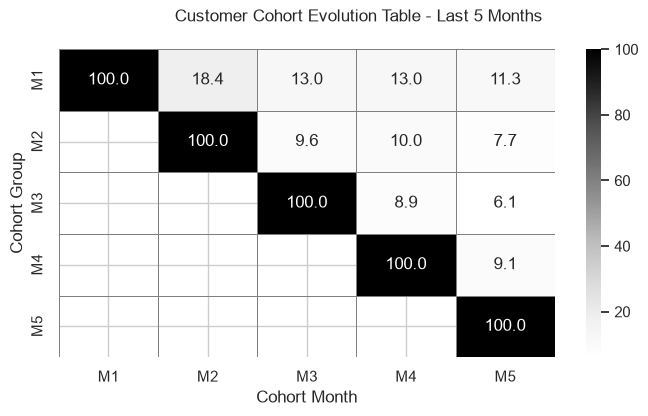

In [17]:
plt.figure(figsize=(8, 4))
sns.heatmap(cohortes, annot=True, fmt=".1f", cmap="Greys", linewidths=0.5, linecolor='gray')
plt.suptitle("Customer Cohort Evolution Table - Last 5 Months", fontsize=12)
plt.xlabel("Cohort Month")
plt.ylabel("Cohort Group")
plt.savefig("../reports/graphics/customer_cohort_analysis_5months.png", dpi=300, bbox_inches="tight")

#### Insight 4: La retención de los clientes es enormemente baja
Despues de analizar la retención de forma aislada en distintos meses, se ha detectado que la retención se mueve entorno al **10% en el segundo mes y en el 8% en el tercer mes. Esto indica que muy pocos clientes son realmente fidelizados con la empresa. Se recomienda crear unplan de fidelizacion del cliente tras su primera compra de forma inmediata.

## 5. Lifetime Value analysis

In [71]:
#tabla de ventas por cliente y mes
sales_ch = (
    df[df.event.eq('purchase')]
    .assign(year_month= lambda x: x['date'].dt.to_period('M'))
    .pivot_table(
        index="user_id",
        columns= "year_month",
        values="price",
        aggfunc="sum",
        fill_value=0
    )
)

In [72]:
#Categorizar clientes segun cohorte (fecha de 1a compra)
month_map = {
    pd.Period("2019-10"): "M1",
    pd.Period("2019-11"): "M2",
    pd.Period("2019-12"): "M3",
    pd.Period("2020-01"): "M4",
    pd.Period("2020-02"): "M5"
}

customers["cohort"] = (
    customers["first_purchase_date"]
    .dt.to_period("M")
    .map(month_map)
)

In [73]:
sales_ch = sales_ch.join(customers["cohort"])

In [75]:
#LTV medio por cliente de cada cohorte
ltv = (
    sales_ch
    .groupby("cohort")
    .sum() #suma total mensual de cada cohorte
    .cumsum(axis=1) #acumulado por mes de cada cohorte
    .div(customers.groupby("cohort").size(), axis=0) #valor medio por customer en cada mes de cada cohorte
)

In [76]:
#Eliminamos M1 ya que NO tiene antecedentes y no podemos usarla en el analisis
ltv.drop(index='M1', inplace=True)

In [77]:
ltv.round(2)

,2019-10,2019-11,2019-12,2020-01,2020-02
cohort,,,,,
M2,0.00,44.42,49.07,54.68,59.11
M3,0.00,0.00,38.13,42.55,45.22
M4,0.00,0.00,0.00,43.22,47.75
M5,0.00,0.00,0.00,0.00,42.21


In [78]:
# Tabla LTV  con valores ajustados a la izquierda para poder aplicar operaciones a posterior
ltv_final = pd.DataFrame([row[row.gt(0)].to_list()for _, row in ltv.iterrows()], index=ltv.index)
#Renombrar columnas a edad cohorte
ltv_final.columns = [f"M{i}" for i in range(ltv_final.shape[1])]

In [80]:
# Crecimiento de cada cohorte
ltv_growth = (ltv_final.div(ltv_final["M0"], axis=0).sub(1).mul(100))

ltv_growth.round(2)

,M0,M1,M2,M3
cohort,,,,
M2,0.00,10.47,23.11,33.08
M3,0.00,11.58,18.59,NaN
M4,0.00,10.48,NaN,NaN
M5,0.00,NaN,NaN,NaN


### Insight 5: El LTV crece un 33,08% en tres meses impulsado por una evolución temprana estable

El **LTV medio por cliente alcanza 59,11 a los tres meses**, un **33,08% más que su valor inicial de 44,42**. Además, las cohortes comparables muestran un crecimiento consistente de aproximadamente **10–12% durante el primer mes**, lo que señala la **recompra temprana como una palanca relevante para incrementar el valor del cliente**. Incentivar la segunda compra y reforzar la retención temprana debería ser una prioridad para maximizar el retorno económico de cada cliente adquirido.


## 6. RFM analysis

### 6.1. RFM Preparation

In [30]:
#segmentos de recencia
customers["recency_segment"] = pd.cut(
    customers["recency_days"],
    bins=[0, 15, 30, 60, 90, np.inf],
    labels=[5, 4, 3, 2, 1]
)

In [31]:
#segmentos de frecuencia (purchase sessions)
customers["frequency_segment"] = (
    customers["purchase_sessions"]
    .clip(upper=5)
)

In [32]:
customers["total_sales_sum"].quantile([0, .2, .4, .6, .8, .95, 1]).to_list()

[0.13, 14.13, 24.6, 41.494, 73.48, 188.8919999999995, 1559.21]

In [33]:
#porcentaje de clientes que gastan mas de 200
customers[customers["total_sales_sum"] > 200].total_sales_sum.count() / customers.total_sales_sum.count() * 100

np.float64(4.5561594202898545)

In [34]:
#segmentos de total sales
customers["total_sales_segment"] = pd.cut(
    customers["total_sales_sum"],
    bins=[0, 25, 50, 100, 250, float("inf")],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True,
    ordered=True
)

In [35]:
#variable RFM para generar un rating para cada cliente
customers['RFM'] = customers.recency_segment.astype(str) + customers.frequency_segment.astype(str) + customers.total_sales_segment.astype(str)

In [36]:
#Variables R, F y M PARA analisis
customers[["R", "F", "M"]] = (
    customers["RFM"]
    .str.extract(r"(\d)(\d)(\d)")
    .astype(int)
)

In [38]:
customers[["R", "F", "M"]].describe()

,R,F,M
count,11040.00,11040.00,11040.00
mean,2.46,1.37,2.07
std,1.41,0.85,1.12
min,1.00,1.00,1.00
25%,1.00,1.00,1.00
50%,2.00,1.00,2.00
75%,3.00,1.00,3.00
max,5.00,5.00,5.00


In [39]:
#combinaciones RFM unicas
customers["RFM"].nunique()

110

### 6.2. Segmentacion de clientes

Se va a generar una segmentación basada en los parametros RFM categorizar a los clientes y así poder evaluar oportunidades de negocio de una forma más sencilla. Los paremetros de la segmentación se han hehco de forma manual generando grupos con características únicas y no comunes entre ellos, para que cada grupo sea distinto a otro y así generar una segmentación lo más ajustada posible a la realidad.

In [40]:
# Segmentacion RFM generada manualmente
conditions = [
    # Champions
    customers["R"].ge(4) &
    customers["F"].ge(4) &
    customers["M"].eq(5),

    # At Risk
    customers["R"].le(3) &
    customers["F"].ge(4) &
    customers["M"].ge(4),

    # Loyal Customers
    customers["R"].ge(4) &
    customers["F"].ge(4) &
    customers["M"].between(2, 4),

    # New Customers
    customers["R"].eq(5) &
    customers["F"].le(2),

    # Promising
    customers["R"].between(3, 4) &
    customers["F"].le(2),

    # Potential Loyalists
    customers["R"].ge(3) &
    customers["F"].ge(3),

    # Lost Customers
    customers["R"].eq(1),

    # Hibernating
    customers["R"].eq(2)
]

segments = [
    "Champions",
    "At Risk",
    "Loyal Customers",
    "New Customers",
    "Promising",
    "Potential Loyalists",
    "Lost Customers",
    "Hibernating"
]

customers["rfm_segment"] = np.select(
    conditions,
    segments,
    default="Other"
)

In [41]:
#Comprovacion rapida de segmentos
customers["rfm_segment"].value_counts(dropna=False)

rfm_segment
Lost Customers         4057
Promising              3215
Hibernating            1893
New Customers          1089
Potential Loyalists     344
Loyal Customers         180
Champions               136
At Risk                 126
Name: count, dtype: int64

In [42]:
#Tabla metricas personalizadas por segmento
rfm_segments = (
    customers
    .groupby("rfm_segment")
    .agg(
        customers=("rfm_segment", "size"),
        revenue=("total_sales_sum", "sum"),
        avg_revenue=("total_sales_sum", "mean"),
        avg_purchase_sessions=("purchase_sessions", "mean"),
        avg_purchase_rate=("purchase_session_rate", "mean"),
        avg_products_session=("products_by_session", "mean"),
        avg_sales_session=("sales_by_session", "mean")
    )
    .reset_index()
)

In [43]:
#Añadimos shares a cada segmento
total_customers = len(customers)
total_revenue = customers["total_sales_sum"].sum()

rfm_segments["customer_share"] = (
    rfm_segments["customers"] / total_customers
)

rfm_segments["revenue_share"] = (
    rfm_segments["revenue"] / total_revenue
)

rfm_segments["value_index"] = (
    rfm_segments["revenue_share"] /
    rfm_segments["customer_share"]
)

In [45]:
#Reordenamos segmentos para posterior visualización y ordenamos valores
segment_order = [
    'Champions',
    'At Risk',
    'Loyal Customers',
    'Potential Loyalists',
    'New Customers',
    'Promising',
    'Hibernating',
    'Lost Customers'
 ]

rfm_segments["rfm_segment"] = pd.Categorical(
    rfm_segments["rfm_segment"],
    categories=segment_order,
    ordered=True
)

rfm_segments = (
    rfm_segments
    .sort_values("rfm_segment")
    .reset_index(drop=True)
)

In [47]:
#colores de cada segmento
RFM_COLORS = {
    "Champions": "#2E7D32",
    "Loyal Customers": "#1565C0",
    "Potential Loyalists": "#6A1B9A",
    "New Customers": "#00838F",
    "Promising": "#EF6C00",
    "At Risk": "#C62828",
    "Hibernating": "#757575",
    "Lost Customers": "#263238"
}

### 6.3. Customer distribution

In [59]:
#data para el grafico con variable segmento a str temporal para asegurar orden correcto en el grafico
plot_data = (
    rfm_segments
    .sort_values("customer_share")
    .reset_index(drop=True)
    .assign(rfm_segment=lambda x: x["rfm_segment"].astype(str))
)

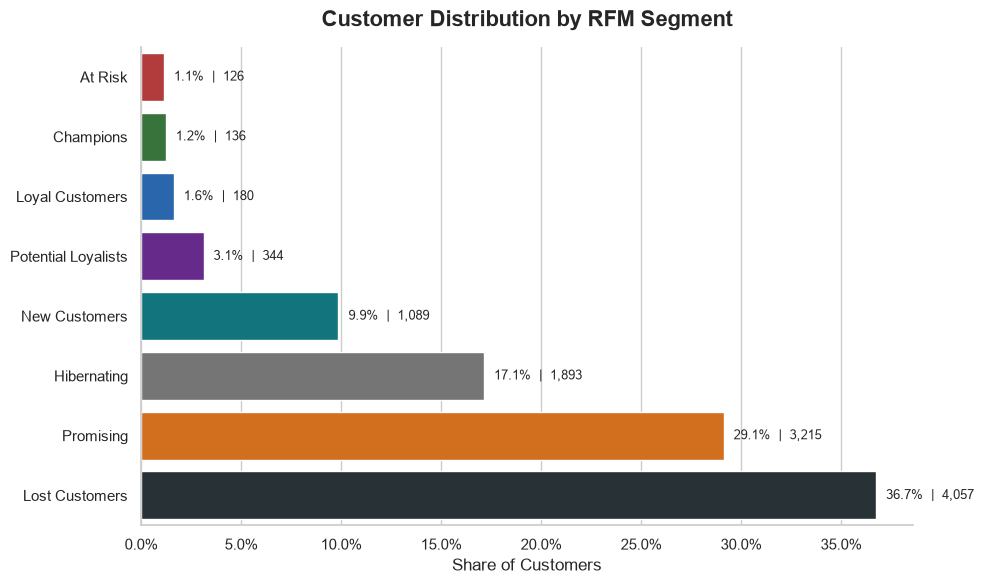

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="customer_share",
    y="rfm_segment",
    hue="rfm_segment",
    palette=RFM_COLORS,
    legend=False,
    ax=ax
)

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_title(
    "Customer Distribution by RFM Segment",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Share of Customers")
ax.set_ylabel("")

for i, row in enumerate(plot_data.itertuples()):
    ax.text(
        row.customer_share + 0.005,
        i,
        f"{row.customer_share:.1%}  |  {row.customers:,}",
        va="center",
        fontsize=9
    )

sns.despine()
plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "rfm_customer_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.4. Revenue contribution

In [61]:
#data para grafico de revenue x segmento
plot_data = (
    rfm_segments
    .sort_values("revenue_share")
    .reset_index(drop=True)
    .assign(rfm_segment=lambda x: x["rfm_segment"].astype(str))
)

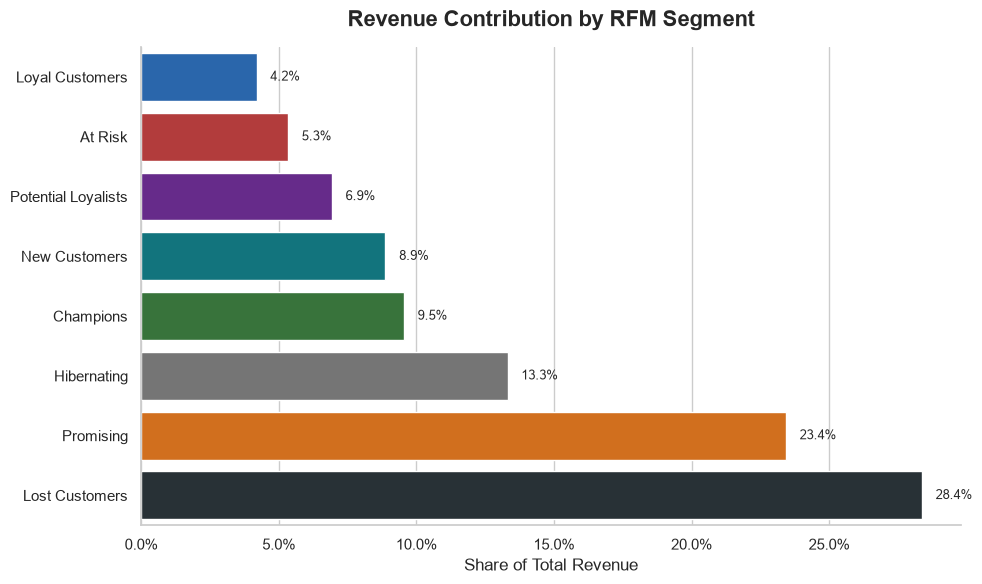

In [ ]:
#grafico de revenue por segmento
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="revenue_share",
    y="rfm_segment",
    hue="rfm_segment",
    palette=RFM_COLORS,
    legend=False,
    ax=ax
)

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_title(
    "Revenue Contribution by RFM Segment",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Share of Total Revenue")
ax.set_ylabel("")

for i, row in enumerate(plot_data.itertuples()):
    ax.text(
        row.revenue_share + 0.005,
        i,
        f"{row.revenue_share:.1%}",
        va="center",
        fontsize=9
    )

sns.despine()
plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "rfm_revenue_contribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.5. Customer share vs revenue share

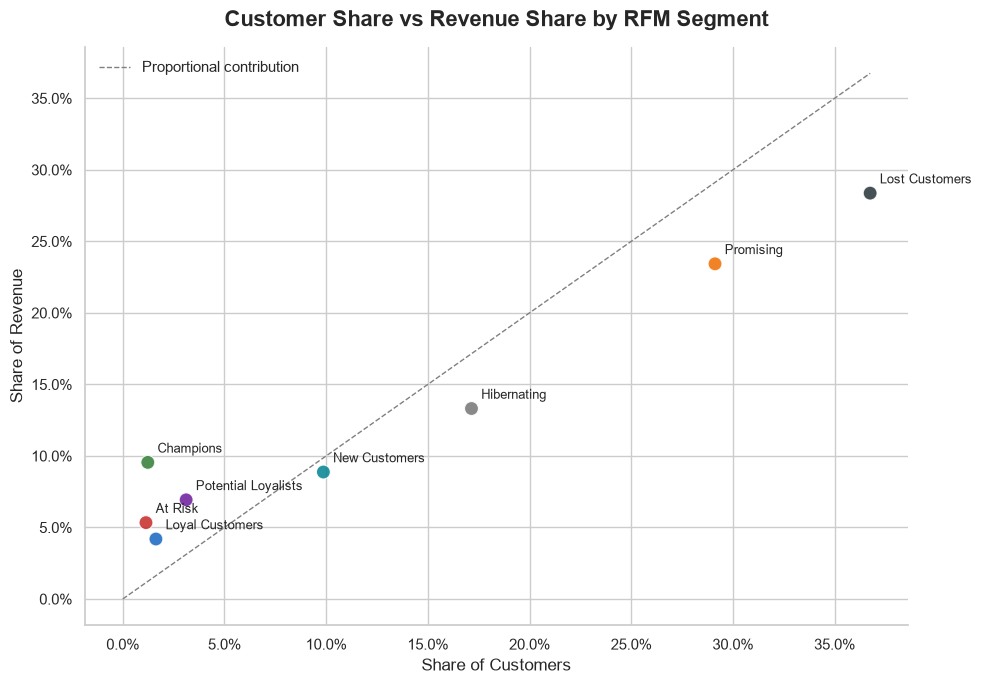

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=rfm_segments,
    x="customer_share",
    y="revenue_share",
    hue="rfm_segment",
    palette=RFM_COLORS,
    s=100,
    alpha=0.85,
    legend=False,
    ax=ax
)
# Reference line: proportional revenue contribution
max_share = max(rfm_segments["customer_share"].max(), rfm_segments["revenue_share"].max())

ax.plot(
    [0, max_share],
    [0, max_share],
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Proportional contribution"
)
# Segment labels
for _, row in rfm_segments.iterrows():
    ax.annotate(
        row["rfm_segment"],
        xy=(
            row["customer_share"],
            row["revenue_share"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_title("Customer Share vs Revenue Share by RFM Segment", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Share of Customers")
ax.set_ylabel("Share of Revenue")

sns.despine()
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "rfm_customer_vs_revenue_share.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.6. RFM Profile

In [ ]:
#dataset para el heatmap de perfiles RFM
rfm_profile = (
    customers
    .groupby("rfm_segment")[["R", "F", "M"]]
    .mean()
    .reindex(segment_order)
)
rfm_profile.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

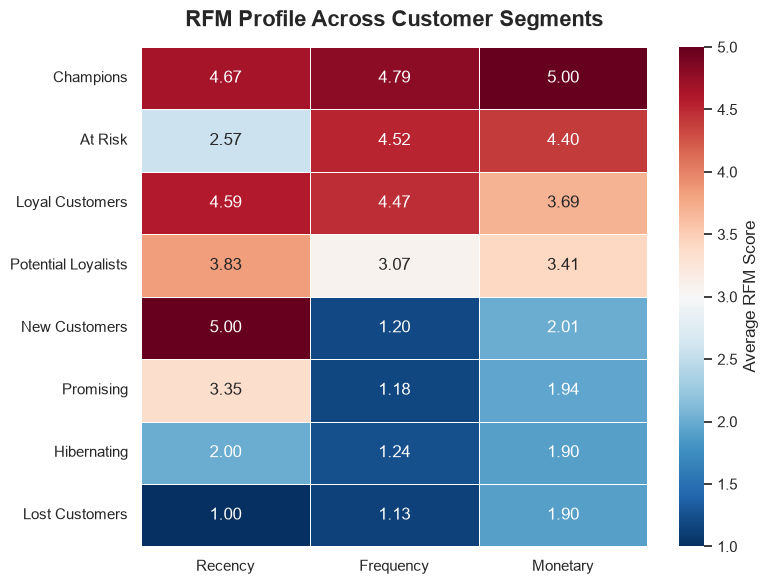

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    rfm_profile,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=1,
    vmax=5,
    linewidths=0.5,
    cbar_kws={
        "label": "Average RFM Score"
    },
    ax=ax
)
ax.set_title("RFM Profile Across Customer Segments", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "rfm_segment_profile.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.7. Behavioral Profile

In [ ]:
#comportamiento de compra por segmento
behavior_cols = [
    "purchase_session_rate",
    "products_by_session",
    "sales_by_session"
]
#calculamos medias de las variables
behavior_profile = (
    customers
    .groupby("rfm_segment")[behavior_cols]
    .mean()
    .reindex(segment_order)
)

In [ ]:
#normalizar valores de los segmentos contra la media global de clientes
behavior_index = (
    behavior_profile /
    customers[behavior_cols].mean()
)

In [93]:
behavior_labels = [
    "Purchase Session Rate",
    "Products by Session",
    "Sales by Session"
]
behavior_index.columns = behavior_labels
behavior_index

,Purchase Session Rate,Products by Session,Sales by Session
rfm_segment,,,
Champions,0.55,2.05,1.84
At Risk,0.55,1.44,1.34
Loyal Customers,0.60,0.92,0.78
Potential Loyalists,0.63,1.22,1.08
New Customers,1.10,1.06,1.06
Promising,1.01,0.97,0.99
Hibernating,1.03,0.88,0.91
Lost Customers,1.03,1.00,1.00


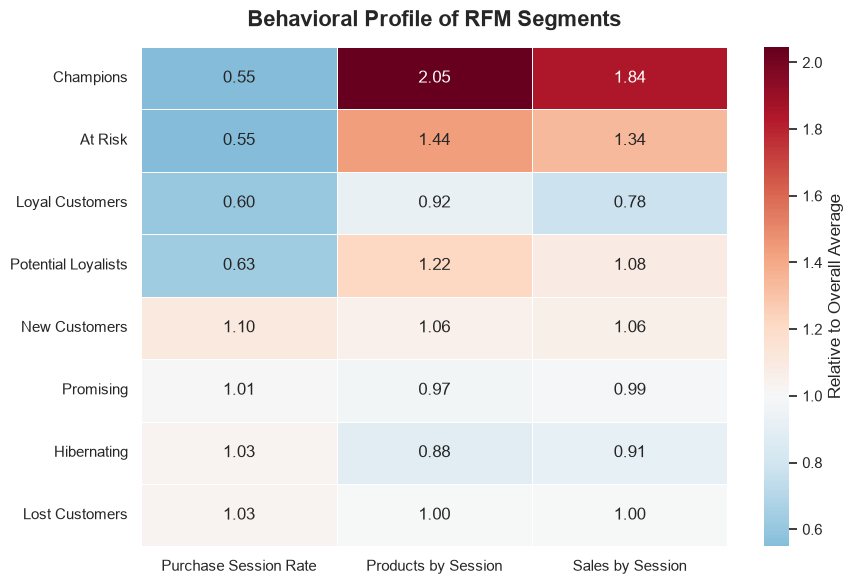

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    behavior_index,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=1,
    linewidths=0.5,
    cbar_kws={
        "label": "Relative to Overall Average"
    },
    ax=ax
)
ax.set_title( "Behavioral Profile of RFM Segments", fontsize=16, fontweight="bold", pad=15)

ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "rfm_behavioral_profile.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.8. Economic Value Index by Customer Segment

In [96]:
#data para grafico de value index de cada segmento
plot_data = (
    rfm_segments
    .sort_values("value_index")
    .reset_index(drop=True)
    .assign(rfm_segment=lambda x: x["rfm_segment"].astype(str))
)

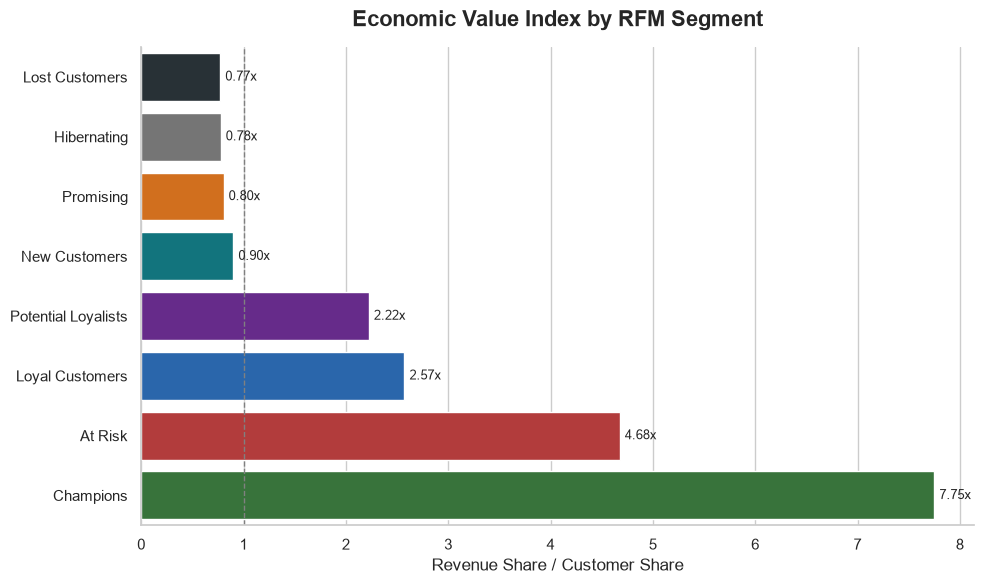

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="value_index",
    y="rfm_segment",
    hue="rfm_segment",
    palette=RFM_COLORS,
    legend=False,
    ax=ax
)
ax.axvline(1, linestyle="--", color="gray", linewidth=1)
ax.set_title("Economic Value Index by RFM Segment", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Revenue Share / Customer Share")
ax.set_ylabel("")

for i, row in enumerate(plot_data.itertuples()):
    ax.text(
        row.value_index + 0.05,
        i,
        f"{row.value_index:.2f}x",
        va="center",
        fontsize=9
    )

sns.despine()
plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "rfm_value_index.png", dpi=300, bbox_inches="tight")
plt.show()

Los segmentos que muestran un revenue esperado mayor a la media son **Champions, At Risk, Loyal Customers y Potential Loyalists**.

### 6.9. At Risk + Hibernating: revenue exposure

In [ ]:
#dataset para el barplot de segmentos en risego
risk_plot = (
    rfm_segments[
        rfm_segments["rfm_segment"].isin(["At Risk", "Hibernating"])
    ][["rfm_segment", "customer_share", "revenue_share"]]
    .copy()
)

risk_plot["rfm_segment"] = risk_plot["rfm_segment"].astype(str)

risk_plot = risk_plot.melt(
    id_vars="rfm_segment",
    var_name="metric",
    value_name="share"
)

risk_plot["metric"] = risk_plot["metric"].map({
    "customer_share": "Customer Share",
    "revenue_share": "Revenue Share"
})

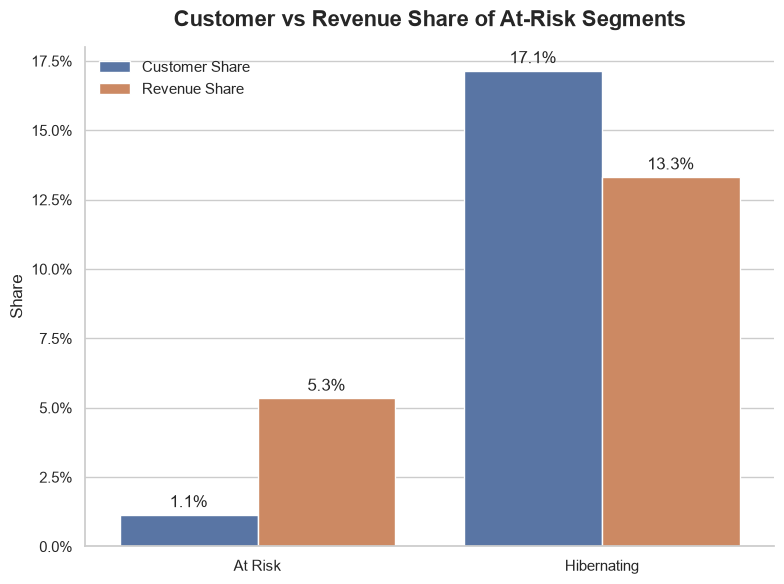

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=risk_plot,
    x="rfm_segment",
    y="share",
    hue="metric",
    order=["At Risk", "Hibernating"],
    ax=ax
)

ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_title("Customer vs Revenue Share of At-Risk Segments", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("Share")

for container in ax.containers:
    labels = [
        f"{value.get_height():.1%}"
        for value in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3
    )

ax.legend(title="", frameon=False, loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "rfm_at_risk_revenue_exposure.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
rfm_segments[["rfm_segment", "customers", "customer_share", "revenue", "revenue_share", "avg_revenue", "value_index"]] \
.sort_values("revenue_share",ascending=False)

,rfm_segment,customers,customer_share,revenue,revenue_share,avg_revenue,value_index
7,Lost Customers,4057,0.37,176342.21,0.28,43.47,0.77
5,Promising,3215,0.29,145626.35,0.23,45.30,0.80
6,Hibernating,1893,0.17,82757.12,0.13,43.72,0.78
0,Champions,136,0.01,59346.23,0.10,436.37,7.75
4,New Customers,1089,0.10,55167.85,0.09,50.66,0.90
3,Potential Loyalists,344,0.03,43074.41,0.07,125.22,2.22
1,At Risk,126,0.01,33175.29,0.05,263.30,4.68
2,Loyal Customers,180,0.02,26060.14,0.04,144.78,2.57


In [ ]:
rfm_segments[["rfm_segment", "avg_purchase_sessions", "avg_purchase_rate", "avg_products_session", "avg_sales_session"]]

,rfm_segment,avg_purchase_sessions,avg_purchase_rate,avg_products_session,avg_sales_session
0,Champions,6.95,0.21,15.62,70.45
1,At Risk,5.17,0.21,10.99,51.15
2,Loyal Customers,5.06,0.23,7.02,29.81
3,Potential Loyalists,3.07,0.24,9.30,41.34
4,New Customers,1.20,0.43,8.06,40.49
5,Promising,1.18,0.39,7.44,37.97
6,Hibernating,1.24,0.40,6.75,34.85
7,Lost Customers,1.13,0.40,7.60,38.09


### Insight 6: Insights estratégicos de segmentación RFM

#### 6.1. Promising y Hibernating concentran una parte importante del valor potencial

**Promising (29,1%) y Hibernating (17,1%) representan el 46,2% de los clientes y generan el 36,4% del revenue histórico**, convirtiéndose en los principales segmentos sobre los que aplicar estrategias de retención y conversión.

#### 6.2. Una parte significativa del revenue procede de segmentos aún no fidelizados

**Promising, Hibernating, At Risk y New Customers concentran el 50,5% del revenue histórico**, mientras que At Risk y Hibernating generan conjuntamente más revenue que Loyal Customers. Diseñar acciones específicas para cada segmento podría convertir parte de este valor en ingresos recurrentes más estables.

#### 6.3. At Risk concentra un valor económico desproporcionado

Aunque **At Risk representa solo el 1,1% de los clientes, genera el 5,3% del revenue**, con un **value index de 4,68x**. Su elevado valor económico justifica priorizar acciones de retención y reactivación antes de que estos clientes evolucionen hacia segmentos de menor valor.

#### 6.4. Champions justifican una estrategia comercial diferenciada

Los **Champions generan el 9,6% del revenue con solo el 1,2% de los clientes**, alcanzando un **value index de 7,75x**. Además, registran **15,62 productos por sesión y 70,45 de ventas por sesión**, muy por encima de Loyal Customers. Este comportamiento podría ser compatible con clientes que realizan compras de mayor volumen, potencialmente con fines de reventa. Sería interesante identificar este perfil y ofrecerle **seguimiento personalizado, condiciones comerciales y ofertas exclusivas**, creando una relación específica que permita aumentar tanto su fidelización como su volumen de compra.




In [65]:
df.to_parquet("../data/processed/df_analysis.parquet", index=True)
df_event_session.to_parquet("../data/processed/df_event_session.parquet", index=True)